# ⚖️ Notebook 5: Credibility Calibration & Risk Adjustment

**Goal:** Build a revenue-neutral, monotone credibility-weighted risk adjustment factor based on Isolation Forest outlier scores.

**Method:**
1. Score each policy with Isolation Forest → `Outlier_Score`
2. Bin policies into quantile bands of `Outlier_Score`
3. Compute actual-vs-expected (A/E) claim cost per band
4. Credibility-weight each band toward 1.0: $Z = \dfrac{n}{n + k}$
5. Enforce monotone smoothing (isotonic regression)
6. Renormalise to be revenue-neutral (exposure-weighted mean = 1.0)

**Inputs:** `outputs/df_with_severity.parquet`, `outputs/meta.json`

**Output saved:** `outputs/df_with_adj.parquet`, `outputs/credibility_model.pkl`, `outputs/credibility_results.json`

---

## 5.1 — Load Data

In [1]:
import pandas as pd
import numpy as np
import json, pickle, warnings
warnings.filterwarnings('ignore')

df   = pd.read_parquet('../outputs/df_with_severity.parquet')
meta = json.load(open('../outputs/meta.json'))

CLAIM_COUNT_COL  = meta['claim_count_col']
CLAIM_AMOUNT_COL = meta['claim_amount_col']
NUM_COLS         = meta['num_cols']
CAT_COLS         = meta['cat_cols']

print(f'Dataset shape: {df.shape}')

Dataset shape: (111615, 14)


## 5.2 — Isolation Forest: Outlier Score

In [2]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Feature matrix for outlier detection (numeric features only)
X_iso = df[NUM_COLS].fillna(df[NUM_COLS].median())
scaler_iso = StandardScaler()
X_iso_scaled = scaler_iso.fit_transform(X_iso)

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # expected ~5% outlier rate
    random_state=42
)
iso_model.fit(X_iso_scaled)

# Score: more negative = more anomalous. We negate so higher = more outlier-like
df['Outlier_Score'] = -iso_model.score_samples(X_iso_scaled)

print(f'Outlier_Score — Min: {df["Outlier_Score"].min():.4f}  Mean: {df["Outlier_Score"].mean():.4f}  Max: {df["Outlier_Score"].max():.4f}')

Outlier_Score — Min: 0.3879  Mean: 0.4580  Max: 0.7649


## 5.3 — Pure Premium per Policy

In [3]:
def tool_calculate_pure_premium(df, freq_col, sev_col, claim_amount_col):
    """
    Multiplies modeled annual frequency by expected severity to compute Pure Premium.
    
    What this tool does:
        Computes baseline technical risk premium: PurePremium = E[Freq] * E[Sev],
        and extracts observed claim losses for calibration.
        
    Returns:
        pd.DataFrame: df with added 'PurePremium_Model' and 'Actual_Cost' columns.
    """
    df['PurePremium_Model'] = df[freq_col] * df[sev_col]
    df['Actual_Cost'] = df[claim_amount_col].fillna(0)
    return df

# ── Run Execution ─────────────────────────────────────────────────────────────
df = tool_calculate_pure_premium(df, 'Freq_Pred', 'Sev_Pred', CLAIM_AMOUNT_COL)

print(f'Pure Premium (model) — Mean: {df["PurePremium_Model"].mean():.2f}')
print(f'Actual Claim Cost     — Mean: {df["Actual_Cost"].mean():.2f}')
print(f'Overall Portfolio A/E       : {df["Actual_Cost"].sum() / df["PurePremium_Model"].sum():.4f}')


Pure Premium (model) — Mean: 75.86
Actual Claim Cost     — Mean: 75.97
Overall Portfolio A/E       : 1.0014


## 5.4 — Credibility Calibration

**You can tune the parameters below:**
- `N_BINS`: Number of quantile bands (default 10)
- `K`: Bühlmann credibility constant (higher = more shrinkage toward 1.0)

In [4]:
from sklearn.isotonic import IsotonicRegression

def tool_calibrate_buhlmann_credibility(df, score_col, actual_col, exp_col, n_bins=10, K=200):
    """
    Calibrates empirical Bayes Bühlmann credibility weights and applies isotonic smoothing.
    
    What this tool does:
        Segments portfolio into quantile bins, computes Z = n / (n + K), blends observed
        loss ratio with unity, enforces monotonicity via IsotonicRegression, and scales
        for revenue neutrality: sum(Expected * Factor) == sum(Actual).
        
    Returns:
        tuple: (ae_table_df, bin_edges, smooth_factors, norm_const, per_policy_factors)
    """
    s = df[score_col].values
    a = df[actual_col].values
    e = df[exp_col].values
    
    bin_edges = np.quantile(s, np.linspace(0, 1, n_bins + 1))
    bin_edges[0]  -= 1e-6
    bin_edges[-1] += 1e-6
    
    bands = np.digitize(s, bin_edges) - 1
    bands = np.clip(bands, 0, n_bins - 1)
    
    rows = []
    for b in range(n_bins):
        mask = bands == b
        nb = mask.sum()
        act = a[mask].sum()
        exp = e[mask].sum()
        raw_ae = act / exp if exp > 0 else 1.0
        Z = nb / (nb + K)
        buhlmann = Z * raw_ae + (1.0 - Z) * 1.0
        rows.append({
            'Band': b + 1,
            'Score_Min': bin_edges[b],
            'Score_Max': bin_edges[b + 1],
            'n': int(nb),
            'Actual_Loss': act,
            'Expected_Loss': exp,
            'Raw_AE': raw_ae,
            'Z_credibility': Z,
            'Buhlmann_Factor': buhlmann
        })
        
    ae_table = pd.DataFrame(rows)
    
    # Monotonic smoothing
    iso = IsotonicRegression(increasing=True, out_of_bounds='clip')
    valid = ae_table[ae_table['n'] > 0]
    midpoints = (valid['Score_Min'] + valid['Score_Max']) / 2.0
    smooth_factors = iso.fit_transform(midpoints, valid['Buhlmann_Factor'])
    ae_table.loc[valid.index, 'Smooth_Factor'] = smooth_factors
    
    # Revenue-neutral scaling
    per_policy_raw = np.array([smooth_factors[b] for b in bands])
    norm_const = a.sum() / (e * per_policy_raw).sum()
    per_policy_final = per_policy_raw * norm_const
    ae_table['Final_Factor'] = ae_table['Smooth_Factor'] * norm_const
    
    return ae_table, bin_edges, smooth_factors, norm_const, per_policy_final, iso

# ── Run Execution ─────────────────────────────────────────────────────────────
N_BINS = 10
K      = 200

ae_table, bin_edges, smooth_factors, norm_const, per_policy_final, iso = (
    tool_calibrate_buhlmann_credibility(
        df, 'Outlier_Score', 'Actual_Cost', 'PurePremium_Model', n_bins=N_BINS, K=K
    )
)

print(f'Bühlmann K         : {K}')
print(f'Normalising const  : {norm_const:.6f}  (revenue-neutral scaling)')
print(f'Factor range       : {ae_table["Final_Factor"].min():.3f} – {ae_table["Final_Factor"].max():.3f}')
display(ae_table[['Band','n','Raw_AE','Z_credibility','Buhlmann_Factor','Smooth_Factor','Final_Factor']].round(4))


Bühlmann K         : 200
Normalising const  : 1.000549  (revenue-neutral scaling)
Factor range       : 0.879 – 1.197


,Band,n,Raw_AE,Z_credibility,Buhlmann_Factor,Smooth_Factor,Final_Factor
0,1,11161,0.8811,0.9824,0.8831,0.8787,0.8792
1,2,11162,1.0585,0.9824,1.0574,0.8787,0.8792
2,3,11162,0.6901,0.9824,0.6955,0.8787,0.8792
3,4,11161,0.9920,0.9824,0.9922,0.9550,0.9556
4,5,11161,0.9164,0.9824,0.9179,0.9550,0.9556
5,6,11162,1.3344,0.9824,1.3286,1.0284,1.0289
6,7,11161,0.8111,0.9824,0.8144,1.0284,1.0289
7,8,11162,0.9411,0.9824,0.9422,1.0284,1.0289
8,9,11161,1.2827,0.9824,1.2778,1.1962,1.1968
9,10,11162,1.1167,0.9824,1.1146,1.1962,1.1968


## 5.5 — A/E Table Visualisation

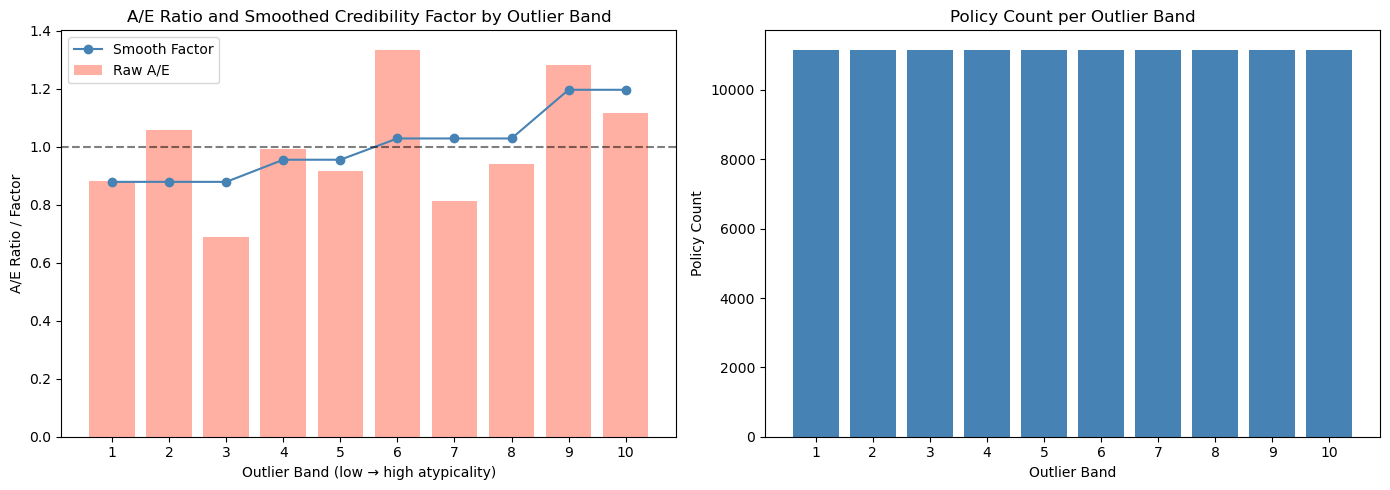

Revenue-neutral check: weighted mean factor = 1.002916  (should be ~1.0)


In [5]:
import matplotlib.pyplot as plt

valid = ae_table[ae_table['n'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw A/E vs smoothed factor
axes[0].bar(valid['Band'].astype(str), valid['Raw_AE'],    alpha=0.5, label='Raw A/E',        color='tomato')
axes[0].plot(valid['Band'].astype(str), valid['Smooth_Factor'], marker='o', label='Smooth Factor', color='steelblue')
axes[0].axhline(1.0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('A/E Ratio and Smoothed Credibility Factor by Outlier Band')
axes[0].set_xlabel('Outlier Band (low → high atypicality)')
axes[0].set_ylabel('A/E Ratio / Factor')
axes[0].legend()

# Band sizes
axes[1].bar(valid['Band'].astype(str), valid['n'], color='steelblue')
axes[1].set_title('Policy Count per Outlier Band')
axes[1].set_xlabel('Outlier Band')
axes[1].set_ylabel('Policy Count')

plt.tight_layout()
plt.savefig('../outputs/credibility_ae_table.png', dpi=120)
plt.show()

print(f'Revenue-neutral check: weighted mean factor = {per_policy_final.mean():.6f}  (should be ~1.0)')

## 5.6 — Save Outputs

In [6]:
def tool_enforce_revenue_neutrality(df, per_policy_factors, output_path, cred_model_dict, model_path):
    """
    Maps balanced Risk Adjustment Factors to policies and serializes calibration model.
    
    What this tool does:
        Applies policy-level Risk_Adj_Factor, confirms portfolio revenue neutrality,
        saves df_with_adj.parquet, and exports credibility_model.pkl.
        
    Returns:
        pd.DataFrame: df with Risk_Adj_Factor attached.
    """
    df['Risk_Adj_Factor'] = per_policy_factors
    df.to_parquet(output_path, index=False)
    
    with open(model_path, 'wb') as f:
        pickle.dump(cred_model_dict, f)
        
    return df

# ── Run Execution ─────────────────────────────────────────────────────────────
cred_model = {
    'iso_model':      iso_model,
    'scaler_iso':     scaler_iso,
    'isotonic':       iso,
    'bin_edges':      bin_edges,
    'smooth_factors': smooth_factors,
    'norm_const':     norm_const,
    'K':              K
}

df = tool_enforce_revenue_neutrality(
    df, per_policy_final,
    '../outputs/df_with_adj.parquet',
    cred_model,
    '../outputs/credibility_model.pkl'
)

cred_res = {
    'K':                 K,
    'N_BINS':            N_BINS,
    'norm_const':        round(float(norm_const), 6),
    'factor_min':        round(float(ae_table['Final_Factor'].min()), 4),
    'factor_max':        round(float(ae_table['Final_Factor'].max()), 4),
    'ae_table':          ae_table.round(4).to_dict(orient='records')
}
with open('../outputs/credibility_results.json','w') as f:
    json.dump(cred_res, f, indent=2)

print('✅ outputs/df_with_adj.parquet')
print('✅ outputs/credibility_model.pkl')
print('✅ outputs/credibility_results.json')


✅ outputs/df_with_adj.parquet
✅ outputs/credibility_model.pkl
✅ outputs/credibility_results.json
